In [1]:
# Libraries & Formatting

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

In [2]:
# 1. Load Dataset

df = pd.read_csv("wdbc.csv")

# Features capturing tumour morphology
features = ["radius_mean", "texture_mean", "smoothness_mean", "concavity_mean"]
X = df[features]

# Convert diagnosis labels to numerical (M = malignant = 1, B = benign = 0)
y = df["Diagnosis"].map({"M": 1, "B": 0})

In [3]:
# 2. Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [4]:
# 3. Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# 4. Logistic Regression Model

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("Model Accuracy on Test Set:", model.score(X_test_scaled, y_test))

print("\nFeature Coefficients (importance):")
for f, c in zip(features, model.coef_[0]):
    print(f"{f}: {c:.4f}")

Model Accuracy on Test Set: 0.9649122807017544

Feature Coefficients (importance):
radius_mean: 3.2381
texture_mean: 1.2857
smoothness_mean: 1.1901
concavity_mean: 1.3159



AUC: 0.9924664264657714


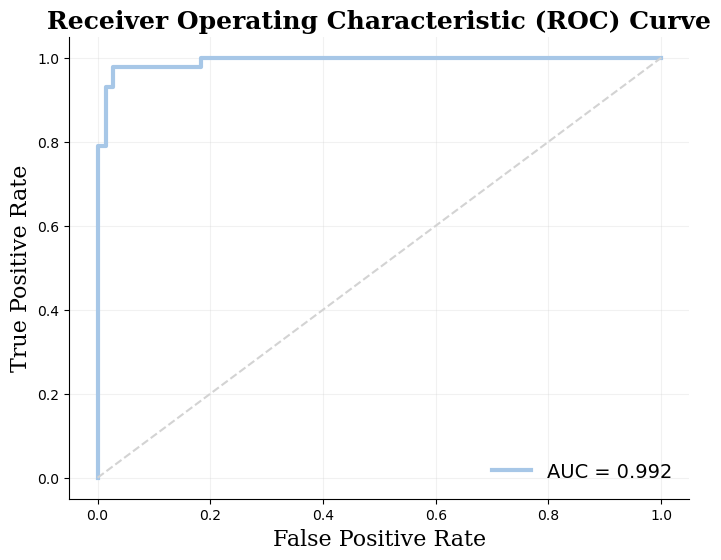

In [6]:
# 5. ROC Curve + AUC

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print("\nAUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))

# Pastel lavender ROC line
plt.plot(fpr, tpr, color="#A7C7E7", linewidth=3, label=f"AUC = {auc:.3f}")

# Baseline
plt.plot([0, 1], [0, 1], linestyle="--", color="lightgray")

plt.title("Receiver Operating Characteristic (ROC) Curve",
          fontsize=18, fontfamily="serif", fontweight="bold")
plt.xlabel("False Positive Rate", fontsize=16, fontfamily="serif")
plt.ylabel("True Positive Rate", fontsize=16, fontfamily="serif")

# Remove clutter borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Light grid to match your R theme
plt.grid(color="lightgray", alpha=0.3)

plt.legend(fontsize=14, frameon=False)
plt.show()

In [7]:
# 6. Morphology Simulation Function

def simulate_prediction(radius, texture, smoothness, concavity):
    """
    Returns predicted malignancy probability for a tumour
    with specified morphological features.
    """

    sample = pd.DataFrame([{
    "radius_mean": radius,
    "texture_mean": texture,
    "smoothness_mean": smoothness,
    "concavity_mean": concavity
    }])

    sample_scaled = scaler.transform(sample)
    
    prob = model.predict_proba(sample_scaled)[0, 1]
    return prob

In [8]:
# 7. Morphology Simulator

# --- input values ---

example_tumours = pd.DataFrame({
    "Description": ["Small, smooth tumour", "Large, concave tumour"],
    "radius_mean": [8, 16],
    "texture_mean": [11, 19],
    "smoothness_mean": [0.20, 0.04],
    "concavity_mean": [0.04, 0.13]
})

example_tumours["Malignancy Probability"] = example_tumours.apply(
    lambda row: simulate_prediction(
        row["radius_mean"], row["texture_mean"],
        row["smoothness_mean"], row["concavity_mean"]
    ),
    axis=1
)

print("\nMorphology Simulation Results:")
print(example_tumours)


Morphology Simulation Results:
             Description  radius_mean  texture_mean  smoothness_mean  concavity_mean  Malignancy Probability
0   Small, smooth tumour            8            11             0.20            0.04                0.311207
1  Large, concave tumour           16            19             0.04            0.13                0.037473
